In [2]:
%pip install -U npc_lims

import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import datetime
import zoneinfo

import npc_lims
from npc_sessions import DynamicRoutingSession
from dynamic_routing_analysis import data_utils, spike_utils


[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


**Copy desired session label from codeocean into s and sessionLabel**

In [3]:
import npc_sessions 
s = npc_sessions.Session('ecephys_801857_2025-09-25_14-08-48')
sessionLabel = 'ecephys_801857_2025-09-25_14-08-48'

**This function will automatically adjust the brain surface coord based on whether a series of consecutive zeros exists above the first chosen value (identified as noise_level). You can adjust the number of consecutive zeros (currently set to 8) and/or the noise level which is currently set to 0.7**

In [4]:
def find_brain_surface(dv_bins: pd.Series, n=8, noise_level=0.7):
    # search for consecutive zeros
    convolution = np.convolve(dv_bins, np.ones(n), mode='valid')
    consecutive_zeros = (convolution < noise_level).nonzero()
    if len(consecutive_zeros) > 0:
        return consecutive_zeros[0][0]*50
    else:
        return len(dv_bins)*50

**Define your injection depth in microns**

In [5]:
injection_depth =1800

**Plot average firing rate along the length of each probe in 50 micron bins and annotate brain surface for each probe**

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_30752\1755573621.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend()


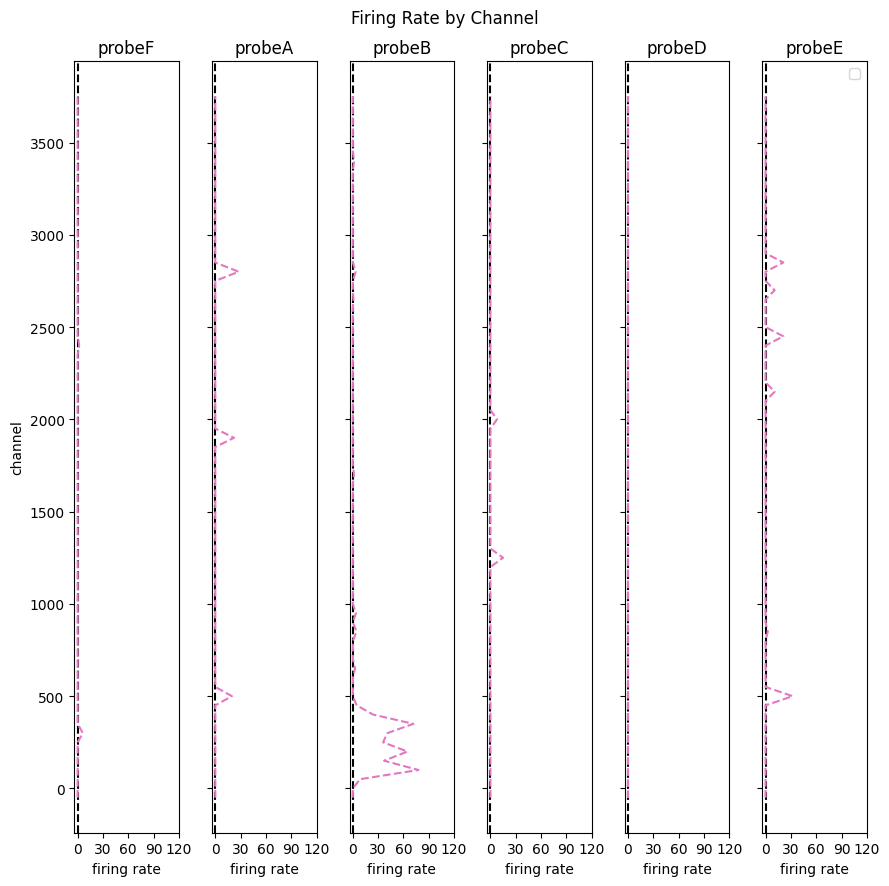

In [6]:
probe_names = ['probeF', 'probeA', 'probeB', 'probeC', 'probeD', 'probeE']
results = {}
results_fr = {}
results_dv = {}
brain_surface_locations = {}
dv_pos_bin_size = 50


for probe in probe_names:
    muscimol_probe_data = s.sorted_data.quality_metrics_df(probe)
    muscimol_unit_locations = s.sorted_data.unit_locations(probe)
    muscimol_probe_data['dv_position'] = muscimol_unit_locations[:, 1]
    muscimol_units_probe = muscimol_probe_data.query(('amplitude_cutoff < 0.1') and ('presence_ratio >= 0.95') and ('isi_violations_ratio < 0.5'))
   

    dv_bins=np.arange(0,3840,dv_pos_bin_size)
    muscimol_probe_unit_densities = []

    for dv_pos in dv_bins:
        muscimol_units_probe_ch = muscimol_units_probe.query('dv_position>=@dv_pos and dv_position<@dv_pos + @dv_pos_bin_size')
        total_firing_rate = np.sum(muscimol_units_probe_ch["firing_rate"].to_numpy())
        muscimol_probe_unit_densities.append(total_firing_rate)

    results[probe] = np.array(muscimol_probe_unit_densities)

probe_data = pd.DataFrame(results)  
fig,ax=plt.subplots(1,6,figsize=(9,9),sharey=True, sharex=True)

# def surface_coord(probe):
#         if probe == 'probeA':
#             a = find_brain_surface(probe_data['probeA'])
#             return a
#         elif probe == 'probeB':
#             b = find_brain_surface(probe_data['probeB'])
#             return b
#         elif probe == 'probeD':
#             c = find_brain_surface(probe_data['probeC'])
#             return c
#         elif probe == 'probeE':
#             d = find_brain_surface(probe_data['probeD'])
#             return d
#         elif probe == 'probeF':
#             e = find_brain_surface(probe_data['probeF'])
#             return e
#         else:
#             return 2000


# surface_coord_dict = {p: probe_data(p) for p in ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']}
# injection_coord_dict = {p:(probe_data(p)- injection_depth) for p in ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']} 


for i,probe in enumerate(probe_names):
    # ax[i].axhline(y = surface_coord_dict[probe], color='black', linestyle='-.', label = 'brain surface')
    #The next line of code is for annotation purposes. Adjust the value in brackets to match which probe corresponds to the injection site
    # ax[-1].axhline(y = injection_coord_dict[probe], color='red', linestyle='-', label = 'injection depth') 
    probe_data_values=probe_data[probe]
    ax[i].axvline(0,color='k',linestyle='--')
    ax[i].plot(probe_data_values, dv_bins - dv_pos_bin_size, color='tab:pink',linestyle='--')
    ax[i].set_title(probe)
    ax[i].set_xlabel('firing rate')
    plt.xticks(np.arange(0, 150, step=30))
    if i==5:
        ax[i].legend()
    elif i==0:
        ax[i].set_ylabel('channel')

fig.suptitle ('Firing Rate by Channel')
fig.tight_layout()

plt.tight_layout()

plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\ephys_muscimol_validation.png", dpi=300)
plt.show()

In [ ]:
#apply a filter to the y axis so we can just see where the firing rate hits zero before and after the injection site annotation. then loop through a bunch of sessions calculating the number of bins near the injection site that have a firing rate below a certain threshold and find the average number of bins that are "silenced" avg distnce around the injection site that is quiet

**Paste an updated ephys tracking sheet with new path**

In [9]:
muscimol_tracking = pd.read_excel(r"C:\Users\vayle.lafehr\Desktop\Perturbations\Ephys Experiment Tracking (1).xlsx", sheet_name='muscimol_tracking')

**Paste appropriate path to import implant coordinate sets**

In [10]:
implant_2005 = pd.read_excel(r"C:\Users\vayle.lafehr\Desktop\Implants\Calculating distance between implant holes\Coordinate Sets - XY wrt Bregma, for Implant Library.xlsx", sheet_name='2005')
implant_2006 = pd.read_excel(r"C:\Users\vayle.lafehr\Desktop\Implants\Calculating distance between implant holes\Coordinate Sets - XY wrt Bregma, for Implant Library.xlsx", sheet_name='2006')
implant_2005 = implant_2005.dropna()
implant_2005.set_index('Point ', inplace = True)
implant_2006.set_index('Point ', inplace = True)

implant_2005["Coordinates"] = implant_2005[["X Coordinate (mm)", "Y Coordinate (mm)"]].astype(str).apply(lambda x: " ".join(x), axis =1)
implant_2006["Coordinates"] = implant_2006[["X Coordinate (mm)", "Y Coordinate (mm)"]].astype(str).apply(lambda x: " ".join(x), axis =1)

implant_2005_dict = implant_2005.to_dict()
implant_2006_dict = implant_2006.to_dict()



**Distance function finds distances between holes by taking implant type and corresponding holes as arguments**

In [11]:
def distance(implant, hole1, hole2):
        if implant == 2005:
                implant = implant_2005_dict
        else:
                implant = implant_2006_dict

        try:
                hole1_x_coord = implant["X Coordinate (mm)"][hole1]
                hole1_y_coord = implant["Y Coordinate (mm)"][hole1]
                hole2_x_coord = implant["X Coordinate (mm)"][hole2]
                hole2_y_coord = implant["Y Coordinate (mm)"][hole2]
        except KeyError as e:
                return 

        hole1 = np.array([[hole1_x_coord, hole1_y_coord]])
        hole2 = np.array([[hole2_x_coord, hole2_y_coord]])
        distance = np.linalg.norm(hole2 - hole1)
        return distance

In [31]:
probe_data

,probeA,probeB,probeC,probeD,probeE,probeF
0,0.000000,0.000000,0.0,0.0,0.0,0.0
1,11.826162,0.000000,0.0,0.0,0.0,0.0
2,0.000000,29.098710,0.0,0.0,0.0,0.0
3,0.000000,1.791773,0.0,0.0,0.0,0.0
4,0.000000,16.997270,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
72,0.000000,0.000000,0.0,0.0,0.0,0.0
73,0.000000,0.000000,0.0,0.0,0.0,0.0
74,0.000000,0.000000,0.0,0.0,0.0,0.0
75,0.000000,0.000000,0.0,0.0,0.0,0.0


**Find firing rate 475 and 525 microns below and above injection coord. Can adjust this number (injection_coord_bins-X:injection_coord_bins+X)**

In [12]:
firing_rates = []

for probe in probe_names:
    injection_coords = find_brain_surface(probe_data[probe]) - injection_depth
    injection_coord_bins = (injection_coords // 50).astype(int)
    probe_data[injection_coord_bins-10:injection_coord_bins+10].mean()
    avg_firing_rate_around_inj_depth = probe_data[injection_coord_bins-10:injection_coord_bins+10].mean()
    firing_rate_near_inj_depth = pd.DataFrame(avg_firing_rate_around_inj_depth)
    firing_rate_near_inj_depth = firing_rate_near_inj_depth.rename(columns={0:'avg_firing_rate'})
    firing_rate_near_inj_depth = firing_rate_near_inj_depth.reset_index(drop=True)
    firing_rates.append(firing_rate_near_inj_depth)

NameError: name 'probe_data' is not defined

**This function finds the distances between each recording probe and the injection site and plots those distances against the corresponding probe's firing rate.**

In [13]:
def plot_probe_firing_by_distance(mouseID, date):
    get_session = muscimol_tracking.loc[(muscimol_tracking['Mouse'] == mouseID) & (muscimol_tracking['Date'] == date)]
    probe_A = distance(get_session.loc[get_session.index.values[0], 'Implant '],get_session.loc[get_session.index.values[0], 'A loc'], get_session.loc[get_session.index.values[0], 'Injection loc'])
    probe_B = distance(get_session.loc[get_session.index.values[0], 'Implant '],get_session.loc[get_session.index.values[0], 'B loc'], get_session.loc[get_session.index.values[0], 'Injection loc'])
    probe_C = distance(get_session.loc[get_session.index.values[0], 'Implant '],get_session.loc[get_session.index.values[0], 'C loc'], get_session.loc[get_session.index.values[0], 'Injection loc'])
    probe_D = distance(get_session.loc[get_session.index.values[0], 'Implant '],get_session.loc[get_session.index.values[0], 'D loc'], get_session.loc[get_session.index.values[0], 'Injection loc'])
    probe_E = distance(get_session.loc[get_session.index.values[0], 'Implant '],get_session.loc[get_session.index.values[0], 'E loc'], get_session.loc[get_session.index.values[0], 'Injection loc'])
    probe_F = distance(get_session.loc[get_session.index.values[0], 'Implant '],get_session.loc[get_session.index.values[0], 'F loc'], get_session.loc[get_session.index.values[0], 'Injection loc'])

    distances = [['probeA', probe_A], ['probeB', probe_B], ['probeC', probe_C], ['probeD', probe_D], ['probeE', probe_E], ['probeF', probe_F]]
    probe_distances = pd.DataFrame(distances, columns=['probe','distance'])

    firing_rate_by_distance = pd.concat([probe_distances, firing_rate_near_inj_depth], axis=1)
    
    ax = firing_rate_by_distance.plot(x='distance', y='avg_firing_rate', kind='scatter', figsize=(8,6))
    plt.xlabel('Distance from muscimol injection site (mm)')
    plt.ylabel('Average firing rate (500 microns above and below injection depth)')
    plt.title('Average firing rate as a function of distance from the injection site')


    for idx, row in firing_rate_by_distance.iterrows():
        ax.annotate(row['probe'], (row['distance'], row['avg_firing_rate']))


    return plt.show()

   

**Pass desired mouseID and date of session through function.**

In [14]:
plot_probe_firing_by_distance(733887, '20240814')

#make a summary plot; give a list of experiments 

NameError: name 'firing_rate_near_inj_depth' is not defined

**Create a list of sessions of interest**


In [21]:
# aggregated_sessions = [(715709, '20240809'), (733887, '20240813'), (733887, '20240814'),(733887, '20240815'), (718283, '20240820'),(718283, '20240821'),(718283, '20240822')]
aggregated_sessions = [(736208, '20240903'), (736208, '20240904'), (736208, '20240805')]

# (718283, '20240823'),(736208,'20240903'),(736208, '20240904'), (736208, '20240905')

In [22]:
# ephys_sessions = ['715709_2024-08-09', '733887_2024-08-14', '736208_2024-09-03', '718283_2024-08-23', '736208_2024-09-04','736208_2024-09-05', '733887_2024-08-15', '718283_2024-08-20', '718283_2024-08-21', '718283_2024-08-22', '736208_2024-09-04']
ephys_sessions = ['736208_2024-09-03', '736208_2024-09-04','736208_2024-09-05']
# '718283_2024-08-23', '736208_2024-09-04',] '733887_2024-08-14', '736803_2024-08-13'
# all_ephys_sessions = [npc_sessions.Session(s) for s in ephys_sessions]

In [37]:
# session = npc_sessions.Session('715709_2024-08-09')

# get_session = muscimol_tracking.loc[(muscimol_tracking['Date'] == session.metadata.timestamps_reference_time.strftime('%Y-%m-%d')) & (muscimol_tracking['Mouse'] == int(session.metadata.subject.subject_id))]
# get_session
# injection_depth = get_session.loc[get_session.index.values[0],'Injection depth']
# injection_depth

**Function that finds the injection depth**

In [23]:
 #finds injection depth
def get_injection_depth(session):
    session = npc_sessions.Session(session)
    get_session = muscimol_tracking.loc[(muscimol_tracking['Date'] == session.metadata.timestamps_reference_time.strftime('%Y-%m-%d')) & (muscimol_tracking['Mouse'] == int(session.metadata.subject.subject_id))]
    injection_depth = get_session.loc[get_session.index.values[0],'Injection depth']
    return injection_depth
# get_injection_depth('733887_2024-08-14')
# [get_injection_depth(session) for session in ephys_sessions]

In [ ]:
# def get_firing_rate_near_inj_depth(session):
#     firing_rates = []
#     for probe in probe_names:
#         injection_coords = find_brain_surface(probe_data[probe]) - (get_injection_depth(session))
#         injection_coord_bins = (injection_coords // 50).astype(int)
#         probe_data[injection_coord_bins-10:injection_coord_bins+10].mean()
#         avg_firing_rate_around_inj_depth = probe_data[injection_coord_bins-10:injection_coord_bins+10].mean()
#         firing_rate_near_inj_depth = pd.DataFrame(avg_firing_rate_around_inj_depth)
#         firing_rate_near_inj_depth = firing_rate_near_inj_depth.rename(columns={0:'avg_firing_rate'})
#         firing_rate_near_inj_depth = firing_rate_near_inj_depth.reset_index(drop=True)
#         return firing_rates.append(firing_rate_near_inj_depth)

In [24]:
#loop through a function that pulls out firing rate for unique injection depth and creates a table for the given session
# for session in all_ephys_sessions:

def get_injection_site_firing_rate(session):
    # try:
    injection_depth = (get_injection_depth(session))
    probe_names = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']
    results = {}
    # results_fr = {}
    # results_dv = {}
    # brain_surface_locations = {}
    dv_pos_bin_size = 50

    for probe in probe_names:
        try:
            muscimol_probe_data = (npc_sessions.Session(session)).sorted_data.quality_metrics_df(probe)
            muscimol_unit_locations = (npc_sessions.Session(session)).sorted_data.unit_locations(probe)
            muscimol_probe_data['dv_position'] = muscimol_unit_locations[:, 1]
            muscimol_units_probe = muscimol_probe_data.query(('amplitude_cutoff < 0.1') and ('presence_ratio >= 0.95') and ('isi_violations_ratio < 0.5'))

            dv_bins=np.arange(0,3840,dv_pos_bin_size)
            muscimol_probe_unit_densities = []

            for dv_pos in dv_bins:
                muscimol_units_probe_ch = muscimol_units_probe.query('dv_position>=@dv_pos and dv_position<@dv_pos + @dv_pos_bin_size')
                total_firing_rate = np.sum(muscimol_units_probe_ch["firing_rate"].to_numpy())
                # print(total_firing_rate)
                # print(muscimol_units_probe_ch)
                muscimol_probe_unit_densities.append(total_firing_rate)

            results[probe] = np.array(muscimol_probe_unit_densities)
        except Exception as e:
            continue

    probe_data = pd.DataFrame(results)

    for probe in probe_names:
            try:
                injection_coords = find_brain_surface(probe_data[probe]) - (get_injection_depth(session))
                injection_coord_bins = (injection_coords // 50).astype(int)
                probe_data[injection_coord_bins-10:injection_coord_bins+10].mean()
                avg_firing_rate_around_inj_depth = probe_data[injection_coord_bins-10:injection_coord_bins+10].mean()
                firing_rate_near_inj_depth = pd.DataFrame(avg_firing_rate_around_inj_depth)
                firing_rate_near_inj_depth = firing_rate_near_inj_depth.rename(columns={0:'avg_firing_rate'})
                firing_rate_near_inj_depth = firing_rate_near_inj_depth.reset_index(drop=True)
            except Exception as e:
                 continue
                # firing_rates.update(firing_rate_near_inj_depth)
    return firing_rate_near_inj_depth


    #         table = firing_rate(session)
# get_injection_site_firing_rate('715709_2024-08-09')
# get_injection_depth('718283_2024-08-03')

In [25]:
muscimol_tracking

,Date,Mouse,Implant,Dye,Probes in brain,Insertion config,Stims run,A loc,A depth,A inj distance,...,Injection loc,drug concentration (ug/ul),Injection rate,Settle time (minutes post-injection),Time inj finished,inner diameter of glass pipette (microns),Beveled 30 degrees,Injection depth,Labeling injection site notes,notes
0,2024-05-07,703881,2006,x,no probes,NaN,"mapping, task",NaN,NaN,NaN,...,C1,NaN,2 nL/sec,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,2024-05-08,703881,2006,x,no probes,NaN,task,NaN,NaN,NaN,...,C1,1 (old mix),2 nL/sec,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,2024-05-09,703881,2006,DiO,ABEF,VISp,"mapping, task",A2,1000,5.889,...,C1,1,2 nL/sec,NaN,NaN,NaN,0.0,NaN,NaN,pre-insertion image has incorrect placements (...
3,2024-05-10,703881,2006,x,no probes,NaN,"task, spont rewards",NaN,NaN,NaN,...,C1,NaN,2 nL/sec,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,2024-05-13,708020,2005,x,no probes,NaN,"task, mapping, spont rewards",NaN,NaN,NaN,...,C1,NaN,2 nL/sec,NaN,NaN,NaN,0.0,NaN,NaN,NaN
5,2024-05-14,708020,2005,x,no probes,NaN,"task, spont rewards",NaN,NaN,NaN,...,C1,1,2 nL/sec,NaN,NaN,NaN,0.0,NaN,NaN,NaN
6,2024-05-15,708020,2005,x,no probes,NaN,"task, spont rewards",NaN,NaN,NaN,...,C1,NaN,2 nL/sec,NaN,NaN,NaN,0.0,NaN,NaN,NaN
7,2024-05-16,708020,2005,x,no probes,NaN,"task, spont rewards",NaN,NaN,NaN,...,C1,1,2 nL/sec,NaN,NaN,NaN,0.0,NaN,NaN,NaN
8,2024-05-17,708020,2005,DiO,C,VISp,"task, mapping, spont rewards x2",x,0,x,...,C1,1 (old mix),2 nL/sec,NaN,NaN,NaN,0.0,NaN,NaN,NaN
9,2024-06-05,712141,2006,DiO,ABCDEF,"frontal, VISp","mapping, task, mapping",B1,3000,4.559,...,C1,1 (old mix),2 nL/sec,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [26]:
def get_aggregated_probe_firing_by_distance(mouseID, date):
    
    locations = ['A loc', 'B loc', 'C loc', 'D loc', 'E loc', 'F loc']
    probe_distances = {}
    get_session = muscimol_tracking.loc[(muscimol_tracking['Mouse'] == mouseID) & (muscimol_tracking['Date'] == date)]

    for location in locations:
            if get_session.loc[get_session.index.values[0], location] == 'x' and pd.isnull(get_session.loc[get_session.index.values[0], location]):
                continue
            probe_distances[location] = distance(get_session.loc[get_session.index.values[0], 'Implant '], get_session.loc[get_session.index.values[0], location], get_session.loc[get_session.index.values[0], 'Injection loc'])

    #calculating distance
    distances = []
    for location in locations:
        if location in probe_distances:
            distances.append([f'probe{location[0]}', probe_distances[location]])

    probe_distances_df = pd.DataFrame(distances, columns=['probe', 'distance'])
    firing_rate = get_injection_site_firing_rate(f"{mouseID}_{date}")
    # print(firing_rate)
    probe_distances_df['avg_firing_rate'] = firing_rate
    probe_distances_df['session_id'] = (f"{mouseID}_{date}")
    firing_rate_by_distance = probe_distances_df
    # firing_rate_by_distance = np.array(probe_distances_df.values, firing_rate)
    return firing_rate_by_distance



In [27]:
all_data = pd.DataFrame() 

import seaborn as sns

for mouseID, date in aggregated_sessions: 
    table = get_aggregated_probe_firing_by_distance(mouseID, date) 
    if table is not None and not table.empty: 
        table['mouseID'] = mouseID 
        table['date'] = date 
        all_data = pd.concat([all_data, table]) 
    else: print(f"No data available for mouseID {mouseID} on date {date}") 
    # Now plot the combined data plt.figure(figsize=(10, 6)) 

    
    unique_sessions = all_data['session_id'].unique() 
    palette = sns.color_palette("pastel", len(unique_sessions)) 
    color_map = dict(zip(unique_sessions, palette)) 
    # Assign colors based on session_id 
    all_data['color'] = all_data['session_id'].map(color_map)
    for session_id in unique_sessions: 
        session_data = all_data[all_data['session_id'] == session_id] 
        plt.scatter(session_data['distance'], session_data['avg_firing_rate'], c=session_data['color'], label=session_id) 
    # ax = all_data.plot(kind='scatter', x='distance', y='avg_firing_rate', figsize=(10, 6))
    # Add labels and title 
    plt.xlabel('Probe distance from muscimol injection site') 
    plt.ylabel('Average firing rate around muscimol injection site') 
    plt.title('Probe distance from injection site as a function of firing Rate') 
    plt.legend(title='Probes')
    plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[sid], markersize=10, label=sid) for sid in unique_sessions], title='Session ID')

    print(all_data)

KeyError: 'commit'

In [ ]:
# #take an average within distance bins (0-0.5)
# distance_bin_size = 0.5
# # all_data.mean


# dist_bins=np.arange(0,7,distance_bin_size)

# #take all distances less 0.5 and find the mean of the firing rates associated then plot. then take all distances between 0.5 -1 so bin sizes of 0.5

# # for distances in all_data['distances']:
# #     sum distances when dist = dist_bins
# #     .mean
# #     print new df

# new_df = []

# for dist in dist_bins:
#     avg_firing_rates_by_dist = all_data.query('avg_firing_rate>=@dist and avg_firing_rate<@dist+@distance_bin_size')
# print((avg_firing_rates_by_dist))
    # new_df.append(len(avg_firing_rates_by_dist))
    #print(muscimol_probe_unit_densities)   
# x = np.array(new_df)

# y=pd.DataFrame(x)
# print(y)

    probe  distance  avg_firing_rate       session_id  mouseID      date  \
3  probeD   2.02216         6.563928  733887_20240813   733887  20240813   

                                           color  
3  (1.0, 0.7058823529411765, 0.5098039215686274)  


**Aggreagate plot**

In [28]:
dist_bins = 14

# Create bins for the x axis
all_data['x_bins'] = pd.cut(all_data['distance'], bins=dist_bins)

# Calculate the mean of y values for each bin
bin_means = all_data.groupby('x_bins')['avg_firing_rate'].mean()

# Plot the mean of y values for each bin
bin_means.plot(kind='bar')
plt.xlabel('Probe distance from muscimol injection site (mm)')
plt.ylabel('Binned mean of average firing rate at injection site')
plt.title('Firing rate as a function of probe distance from injection site')
plt.show()

KeyError: 'distance'

In [ ]:

#plot average d' by area








In [ ]:
bin_means.plot(kind='bar')
plt.xlabel('Region silenced')
plt.ylabel("Average d'")
plt.title("Average d' as a function of region silenced")
plt.show()